<a href="https://colab.research.google.com/github/ryurikritz/ProjectAIMLYear1May2026/blob/main/Cardiac_Arrest_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem Statement: **


Cardiac arrest is an abrupt loss of heart functioning. The condition generally results from a problem with the heart’s electrical system that disturbs the heart's pumping action. This malfunction can cause a life-threatening condition. Due to cardiac arrest, millions of people die every year. Hence, it would be a lifesaver if we can build a system that is capable of predicting heart failure.

Certain medical parameters help in predicting if a person is at risk of getting a cardiac arrest. Such features are stored in ‘Cardiac.csv’.



Attribute Information-

Gender: This feature represents the gender of a person; 0- Other, 1- Male, 2- Female.
Chain_smoker: This feature represents if the person is a chain smoker or not
Consumes_other_tobacco_products:  This feature represents if the person consumes other tobacco products.
HighBP:  This feature represents if the person has high blood pressure or not.
Obese:  This feature represents if the person is obese or not.
Diabetes:  This feature represents if the person has diabetes or not.
Metabolic_syndrome:  This feature represents if the person has metabolic syndrome or not
Use_of_stimulant_drugs:  This feature represents if the person uses stimulant drugs or not
Family_history:  This feature represents if someone in the family had cardiac issues or not.
History_of_preeclampsia:  This feature represents if the person has a history of preeclampsia.
CABG_history:  This feature represents if the person has a history of Coronary artery bypass surgery or not.
Respiratory_illness:  This feature represents if the person has any respiratory illness.
UnderRisk:  This feature represents if the person is at risk of getting a cardiac arrest or not.


Instructions:

Kindly go through the guidelines before attempting the quiz.



Ensure that there is a proper internet connection while taking up the quiz. Any disruption in the connection will automatically submit your quiz.
Attempt the quiz only when you are prepared and have enough time to finish it. Please ensure you attempt the quiz well before the due date. No extension will be provided for any quiz once the deadline is passed.
The quiz once opened, must be completed within the time frame provided. You CANNOT start the quiz, leave it unattended for an extended period of time and come back later to finish.
Use random_state = 1, wherever applicable.
No re-attempts will be provided if the quiz gets submitted for any of the above-mentioned reasons.
If you face any other technical issues on Olympus, you should share the screenshot with your Program Manager so that the team can understand and resolve it on priority.
Note - Train the models with default parameters unless instructed to use certain hyperparameters.

In [28]:
# Write your code here to import necessary libraries for the project
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

# Import necessary libraries for model building, visualization, and evaluation
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    recall_score, precision_score, f1_score, accuracy_score
)

# Configure visual settings for cleaner notebook outputs
sns.set(style="whitegrid")                 # Sets a clean background style for future Seaborn plots
pd.set_option("display.max_columns", None) # Prevents Pandas from hiding columns in wide dataframes
plt.rcParams["figure.dpi"] = 110           # Increases the resolution of Matplotlib plots for readability

**Understanding the structure of the data**

In [29]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
# Write your code here to read the data
df = pd.read_csv('/content/drive/MyDrive/Cardiac.csv')

In [31]:
# Write your code here to view the first 5 rows
df.head()

,Gender,Chain_smoker,Consumes_other_tobacco_products,HighBP,Obese,Diabetes,Metabolic_syndrome,Use_of_stimulant_drugs,Family_history,History_of_preeclampsia,CABG_history,Respiratory_illness,UnderRisk
0,Male,1,1,0,1,0,0,0,1,0,0,0,no
1,Male,0,1,0,1,0,0,0,1,0,0,0,no
2,Male,0,1,0,1,0,0,0,1,0,0,0,no
3,Male,0,1,0,1,0,0,0,1,0,0,0,no
4,Male,0,0,0,0,0,1,1,0,0,0,0,no


**Finding rows and columns are present in the data**

In [32]:
# Write your code here
# Finding the rows and columns present in the dataset
rows = df.shape[0]
cols = df.shape[1]
print(f'There are {rows} rows and {cols} columns in the dataset.')

There are 889 rows and 13 columns in the dataset.


**Finding the datatypes of the different columns in the dataset**

In [33]:
# Write your code here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Gender                           889 non-null    object
 1   Chain_smoker                     889 non-null    int64 
 2   Consumes_other_tobacco_products  889 non-null    int64 
 3   HighBP                           889 non-null    int64 
 4   Obese                            889 non-null    int64 
 5   Diabetes                         889 non-null    int64 
 6   Metabolic_syndrome               889 non-null    int64 
 7   Use_of_stimulant_drugs           889 non-null    int64 
 8   Family_history                   889 non-null    int64 
 9   History_of_preeclampsia          889 non-null    int64 
 10  CABG_history                     889 non-null    int64 
 11  Respiratory_illness              889 non-null    int64 
 12  UnderRisk                        889

**Are there any missing values in the data?**

In [34]:
# Write your code here
df.isnull().sum()

,0
Gender,0
Chain_smoker,0
Consumes_other_tobacco_products,0
HighBP,0
Obese,0
Diabetes,0
Metabolic_syndrome,0
Use_of_stimulant_drugs,0
Family_history,0
History_of_preeclampsia,0


**Check the statistical summary of the data.**

In [35]:
# Write your code here
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Chain_smoker,889.0,0.120360,0.325565,0.0,0.0,0.0,0.0,1.0
Consumes_other_tobacco_products,889.0,0.838020,0.368640,0.0,1.0,1.0,1.0,1.0
HighBP,889.0,0.086614,0.281427,0.0,0.0,0.0,0.0,1.0
Obese,889.0,0.919010,0.272973,0.0,1.0,1.0,1.0,1.0
Diabetes,889.0,0.055118,0.228339,0.0,0.0,0.0,0.0,1.0
Metabolic_syndrome,889.0,0.042745,0.202395,0.0,0.0,0.0,0.0,1.0
Use_of_stimulant_drugs,889.0,0.082115,0.274694,0.0,0.0,0.0,0.0,1.0
Family_history,889.0,0.925759,0.262310,0.0,1.0,1.0,1.0,1.0
History_of_preeclampsia,889.0,0.017998,0.133018,0.0,0.0,0.0,0.0,1.0
CABG_history,889.0,0.021372,0.144704,0.0,0.0,0.0,0.0,1.0


In [36]:
#Identify the correct percentage of positive (YES) and negative(NO) class distribution
class_distribution = df['UnderRisk'].value_counts(normalize=True) * 100
print(class_distribution)


UnderRisk
no     78.627672
yes    21.372328
Name: proportion, dtype: float64


In [38]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 1. RELOAD THE DATA FROM SCRATCH
# This prevents the "double-mapping" issue if you run this cell multiple times
df = pd.read_csv('/content/drive/MyDrive/Cardiac.csv')

# 2. Data Preprocessing
encoder = LabelEncoder()
df['Gender'] = encoder.fit_transform(df['Gender'])

df['UnderRisk'] = df['UnderRisk'].astype(str).str.strip().str.lower()
df['UnderRisk'] = df['UnderRisk'].map({'yes': 1, 'no': 0})
df = df.dropna(subset=['UnderRisk'])

# 3. Define X and y
X = df.drop('UnderRisk', axis=1)
y = df['UnderRisk']

# 4. Split the dataset
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

# 5. Create dummies
X_train = pd.get_dummies(X_train, drop_first=True)
X_val = pd.get_dummies(X_val, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# 6. Print the results
train_rows = X_train.shape[0]
train_cols = X_train.shape[1]
print(f'There are {train_rows} rows and {train_cols} columns in the training set.')

There are 533 rows and 12 columns in the training set.


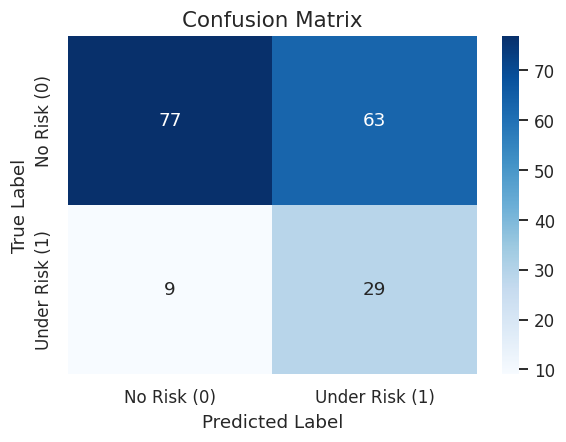

--- Model Evaluation Metrics ---
Accuracy:  59.55%
Precision: 31.52%
Recall:    76.32%  <-- (Crucial metric for False Negatives)
F1 Score:  44.62%


In [39]:
# Assuming 'model' is your trained Logistic Regression model
# and X_test / y_test are your testing sets from the previous steps


# --- The Fix: Add class_weight='balanced' ---
model = LogisticRegression(max_iter=1000, class_weight='balanced')

# Train the model again
model.fit(X_train, y_train)

# Generate new predictions
predictions = model.predict(X_test)

# --- 1. Compute and Display the Confusion Matrix ---
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Risk (0)', 'Under Risk (1)'],
    yticklabels=['No Risk (0)', 'Under Risk (1)']
)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

# --- 2. Calculate the Evaluation Metrics ---
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

# --- 3. Print the Results ---
print("--- Model Evaluation Metrics ---")
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%  <-- (Crucial metric for False Negatives)")
print(f"F1 Score:  {f1 * 100:.2f}%")

In [40]:
# Let's try some other algorithms before settling in on a final model. Train a bagging classifier on the oversampled data using the sklearn implementation with default parameters and random_state =1 and check the model performance on the validation set.

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# --- Step 1: Oversample the training data ---
# (Using SMOTE to balance the minority class)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# --- Step 2: Train the Bagging Classifier ---
# Using default parameters and random_state = 1 as requested
bagging_model = BaggingClassifier(random_state=1)
bagging_model.fit(X_train_resampled, y_train_resampled)

# --- Step 3: Check performance on the validation set ---
y_val_pred = bagging_model.predict(X_val)

# --- Step 4: Display the evaluation metrics ---
print("--- Bagging Classifier Metrics (Validation Set) ---")
print(f"Accuracy:  {accuracy_score(y_val, y_val_pred) * 100:.2f}%")
print(f"Precision: {precision_score(y_val, y_val_pred) * 100:.2f}%")
print(f"Recall:    {recall_score(y_val, y_val_pred) * 100:.2f}%")
print(f"F1-Score:  {f1_score(y_val, y_val_pred) * 100:.2f}%")

--- Bagging Classifier Metrics (Validation Set) ---
Accuracy:  56.18%
Precision: 30.39%
Recall:    81.58%
F1-Score:  44.29%


In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import pandas as pd

# Assuming X_train and y_train have already been created and dummified from the previous steps.
# (Make sure you are using the ORIGINAL X_train, not the SMOTE resampled one)

# --- Step 1: Train a Random Forest Classifier ---
# Using default parameters and random_state = 1
rf_model = RandomForestClassifier(random_state=1)
rf_model.fit(X_train, y_train)

# --- Step 2: Assess performance on the TRAINING set ---
y_train_pred = rf_model.predict(X_train)

# --- Step 3: Check how many observations are correctly predicted ---
# We use a confusion matrix to easily extract the exact number of True Positives
cm = confusion_matrix(y_train, y_train_pred)

# The confusion matrix structure is:
# [[True Negatives (TN), False Positives (FP)]
#  [False Negatives (FN), True Positives (TP)]]

true_positives = cm[1, 1]

print("--- Random Forest Training Performance ---")
print(f"Total True Positives (Correctly predicted as 'yes'): {true_positives}")

--- Random Forest Training Performance ---
Total True Positives (Correctly predicted as 'yes'): 18


In [42]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

from imblearn.over_sampling import SMOTE # Ensure imbalanced-learn is installed

# 1. Ensure oversampled data is defined
# If you don't have imbalanced-learn, use the manual duplication method provided previously
smote = SMOTE(random_state=42)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

# 2. Define the models
models = [
    ("Bagging", BaggingClassifier(random_state=1)),
    ("RandomForest", RandomForestClassifier(random_state=1)),
    ("LogisticRegression", LogisticRegression(random_state=1, max_iter=1000)),
    ("DecisionTree", DecisionTreeClassifier(random_state=1))
]

# 3. Configure Cross-Validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
scoring = "recall"

# 4. Loop through models and get results
print(f"{'Model':<20} | {'Mean Recall':<12}")
print("-" * 35)

for name, model in models:
    cv_result = cross_val_score(estimator=model, X=X_train_over, y=y_train_over, scoring=scoring, cv=kfold)
    print(f"{name:<20} | {cv_result.mean():.4f}")

Model                | Mean Recall 
-----------------------------------
Bagging              | 0.7445
RandomForest         | 0.7517
LogisticRegression   | 0.7445
DecisionTree         | 0.7445


In [43]:
import numpy as np
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn import metrics

# 1. Initialize the base model
# AdaBoost uses Decision Trees as its base estimator by default,
# but we are explicitly defining them in the param_grid.
model = AdaBoostClassifier(random_state=1)

# 2. Define the parameter grid
param_grid = {
    "n_estimators": np.arange(10, 110, 10),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "estimator": [ # Note: 'base_estimator' is deprecated in newer sklearn, use 'estimator'
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

# 3. Define the scorer
scorer = metrics.make_scorer(metrics.recall_score)

# 4. Configure RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_jobs=-1,
    n_iter=50,
    scoring=scorer,
    cv=5,
    random_state=1,
)

# 5. Fit the model to the oversampled training data
randomized_cv.fit(X_train_over, y_train_over)

# 6. View the best parameters and the best score
print("Best Hyperparameters found:")
print(randomized_cv.best_params_)
print(f"\nBest Recall Score: {randomized_cv.best_score_:.4f}")

Best Hyperparameters found:
{'n_estimators': np.int64(50), 'learning_rate': 0.01, 'estimator': DecisionTreeClassifier(max_depth=1, random_state=1)}

Best Recall Score: 1.0000


In [44]:


from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report

# --- 1. Create the UNDERSAMPLED data ---
# This reduces the majority class ('no' risk) to match the minority class ('yes' risk)
rus = RandomUnderSampler(random_state=1)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

# --- 2. Train and Evaluate AdaBoost on UNDERSAMPLED data ---
ada_under = AdaBoostClassifier(random_state=1)
ada_under.fit(X_train_under, y_train_under)

# Evaluate on undersampled training set
pred_under = ada_under.predict(X_train_under)
print("--- AdaBoost Performance (Undersampled Train Data) ---")
print(classification_report(y_train_under, pred_under))

# --- 3. (Optional) Re-run the OVERSAMPLED data if needed ---
# Assuming X_train_over, y_train_over are already defined from your SMOTE step earlier
ada_over = AdaBoostClassifier(random_state=1)
ada_over.fit(X_train_over, y_train_over)

pred_over = ada_over.predict(X_train_over)
print("\n--- AdaBoost Performance (Oversampled Train Data) ---")
print(classification_report(y_train_over, pred_over))

--- AdaBoost Performance (Undersampled Train Data) ---
              precision    recall  f1-score   support

           0       0.86      0.17      0.28       114
           1       0.54      0.97      0.69       114

    accuracy                           0.57       228
   macro avg       0.70      0.57      0.49       228
weighted avg       0.70      0.57      0.49       228


--- AdaBoost Performance (Oversampled Train Data) ---
              precision    recall  f1-score   support

           0       0.92      0.26      0.41       419
           1       0.57      0.98      0.72       419

    accuracy                           0.62       838
   macro avg       0.74      0.62      0.57       838
weighted avg       0.74      0.62      0.57       838



/tmp/ipykernel_917/3584642433.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


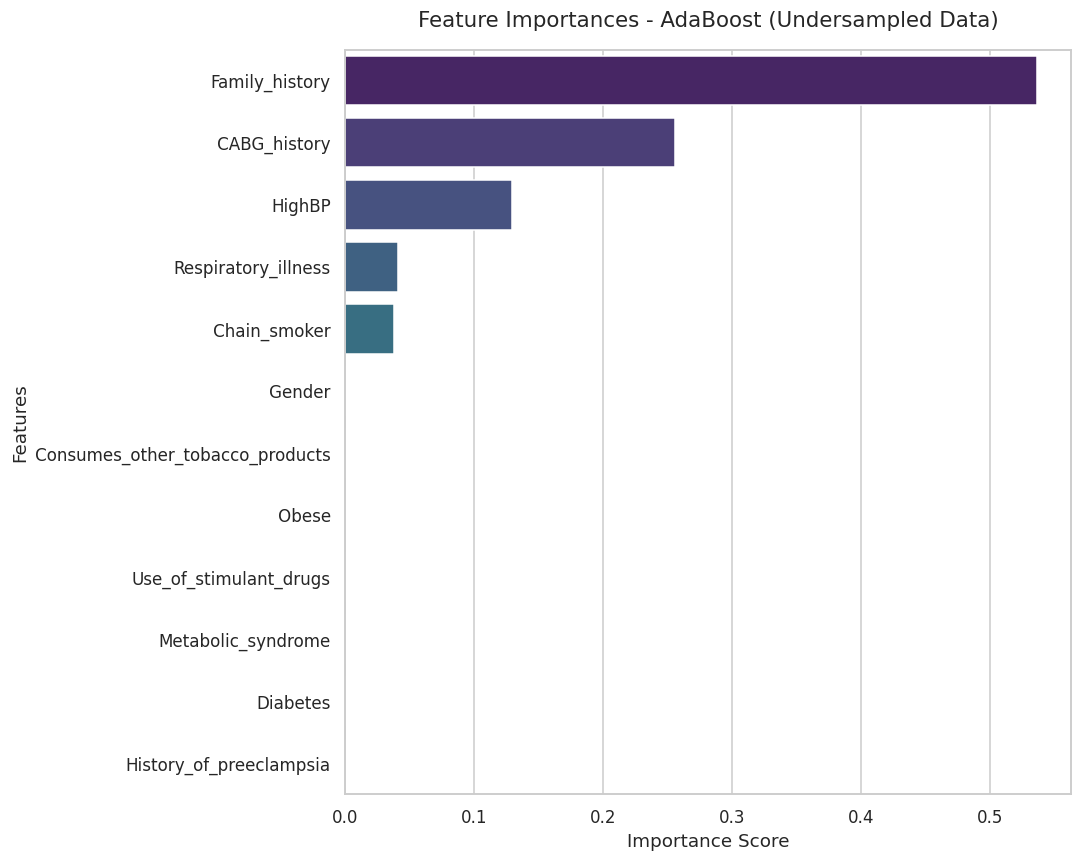

--- Exact Feature Importance Scores ---
                        Feature  Importance
                 Family_history    0.536319
                   CABG_history    0.256011
                         HighBP    0.129198
            Respiratory_illness    0.040905
                   Chain_smoker    0.037568
                         Gender    0.000000
Consumes_other_tobacco_products    0.000000
                          Obese    0.000000
         Use_of_stimulant_drugs    0.000000
             Metabolic_syndrome    0.000000
                       Diabetes    0.000000
        History_of_preeclampsia    0.000000


In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. Extract Feature Importances ---
# Extract the importances from the trained undersampled model
importances = ada_under.feature_importances_

# Get the names of the features from the training dataframe
# (Assuming X_train_under is a pandas DataFrame)
feature_names = X_train_under.columns

# --- 2. Create a DataFrame for Sorting ---
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort the features in descending order so the most important are at the top
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# --- 3. Plot the Feature Importances ---
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

# Add titles and labels for clarity
plt.title('Feature Importances - AdaBoost (Undersampled Data)', fontsize=14, pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

# Ensure everything fits nicely
plt.tight_layout()
plt.show()

# Optional: Print the exact values
print("--- Exact Feature Importance Scores ---")
print(feature_importance_df.to_string(index=False))